<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>Examen : Programmation statistique automatisée</center>
<hr style=" border:none; height:3px;">
</h1>

In [2]:
import pandas as pd

Toute commande, même incomplète ou renvoyant une erreur sera prise en compte. Allez chercher les points !

## 1. Observations d'oiseaux

La documentation du jeu de données est sur Arche.

N'hésitez pas à utiliser ctrl + F pour trouver rapidement un mot dans une page.

1. Stockez le jeu de données `oiseaux.csv` dans la variable `oiseaux`. Affichez les deux dernières lignes de deux façons différentes.

In [11]:
oiseaux = pd.read_csv('oiseaux_gbif.csv',sep=',')

In [12]:
oiseaux.tail(2)

,decimalLatitude,decimalLongitude,species,individualCount,eventDate,day,month,year,departmentCode,speciesLevel,rawLocation
1562595,48.82615,4.66785,Corvus corone,NaN,2019-04-27,27.0,4.0,2019,51.0,1,NaN
1562596,48.99720,6.37214,Linaria cannabina,NaN,2021-04-20,20.0,4.0,2021,57.0,1,MOSELLE


In [13]:
oiseaux.iloc[-2:,:]

,decimalLatitude,decimalLongitude,species,individualCount,eventDate,day,month,year,departmentCode,speciesLevel,rawLocation
1562595,48.82615,4.66785,Corvus corone,NaN,2019-04-27,27.0,4.0,2019,51.0,1,NaN
1562596,48.99720,6.37214,Linaria cannabina,NaN,2021-04-20,20.0,4.0,2021,57.0,1,MOSELLE


2. D'après la documentation et éventuellement des ressources extérieures, que contient le jeu de données ? Contextualisez les données.

* **Quoi** : Ce jeu de données comprend des observations d'oiseaux réalisées dans le Grand-Est entre 2018 et 2022, couplées à des informations sur les départements concernés. Chaque ligne correspond à une observation d'oiseaux à une localisation et une date données.
* **Qui** :
   - Données d'observations agrégées par : GBIF
   - Données départementales produites par : Grégoire David
   - Jeu de données final créé par : Étudiants du BUT Sciences des données de Metz dans le cadre des SAE501 et SAE602
* **Quand** : Années 2018 à 2022.
* **Où** : Grand-Est.
* **Comment** : Assemblage de deux jeux de données dans le cadre d'un projet universitaire.
* **Pourquoi** :
   - Projet universitaire
   - Étudier la biodiversité aviaire de la région Grand-Est

3. Que peut-on dire concernant la qualité *a priori* de ce jeu de données ?

* **Sources fiables** : GBIF, GeoJSON construit à partir des tracés IGN (avec code partagé), projet universitaire.
* **Fiabilité des données élevée** étant donné la fiabilité des sources, protocole de standardisation de GBIF.
* **Résolution spatiale élevée** : Localisations précises.
* **Étendue spatiale limitée** : Grand-Est.
* **Échelle temporelle limitée** : Les données ne couvrent que les années 2018 à 2022.
* **Ancienneté des données** : Les données les plus récentes remontent à 4 ans.

4. À quelle catégorie appartient chaque variable ? Les types sont-ils bien choisis ? Modifiez le type des colonnes si besoin (dans ce cas, utilisez les types spécifique à Pandas : `string`, `Int64`, `Float64`, `boolean`).

**Variables quantitatives continues** : `decimalLatitude`, `decimalLongitude`    
**Variables quantitatives discrètes** : `year`, `month`, `day`, `individualCount`      
**Variables qualitatives nominales** : `species`, `departmentCode`, `speciesLevel`, `rawLocation`     
**Variable qualitative ordinale** : `eventDate`

In [14]:
oiseaux.dtypes

,0
decimalLatitude,float64
decimalLongitude,float64
species,object
individualCount,float64
eventDate,object
day,float64
month,float64
year,int64
departmentCode,float64
speciesLevel,int64


Les types ne sont pas adaptés pour certaines des variables :
* `species` et `rawLocation` sont de type **`object`**. `object` est un type fourre-tout, il est recommandé d'utiliser un type plus spécifique pour les variables concernées lorsque c'est possible. Ici, le type `string` est le type le plus adapté.
* `eventDate` est aussi de type **`object`**. Puisque cette variable contient des dates, le type `datetime` de Pandas est adapté. Le type `string` peut aussi convenir en fonction de l'utilisation prévue.
* `day`, `month` et `individualCount` sont des variables quantitatives **discrètes**, le type `float64` n'est pas adapté. Le type `Int64` serait plus adéquate.
* La variable `departmentCode` est une variable **qualitative discrète**, le type `float64` n'est pas adapté. Le type `string` serait plus adéquate. Puisque le type était `float64`, il faut d'abord convertir en `Int64` pour ne pas conserver la virgule dans la chaîne de caractères.
* La variable `speciesLevel` est une variable qualitative nominale **binaire** : elle ne prend que deux valeurs, 0 ou 1. Puisque cette variable indique si l'organisme est identifié au niveau de l'espèce ou non, le type `boolean` serait plus adapté.

In [15]:
oiseaux[['species','eventDate','rawLocation']] = oiseaux[['species','eventDate','rawLocation']].astype('string')
oiseaux[['individualCount','day','month','year']] = oiseaux[['individualCount','day','month','year']].astype('Int64')
oiseaux['speciesLevel'] = oiseaux['speciesLevel'].astype('boolean')
oiseaux['departmentCode'] = oiseaux['departmentCode'].astype('Int64').astype('string')

oiseaux.dtypes

,0
decimalLatitude,float64
decimalLongitude,float64
species,string[python]
individualCount,Int64
eventDate,string[python]
day,Int64
month,Int64
year,Int64
departmentCode,string[python]
speciesLevel,boolean


5. Renommez la colonne `species` `birdSpecies` pour que tout utilisateur comprenne immédiatement ce que contient le jeu de données. Affichez le nom des colonnes.

In [17]:
oiseaux = oiseaux.rename(columns={'species' : 'birdSpecies'})
oiseaux.columns

Index(['decimalLatitude', 'decimalLongitude', 'birdSpecies', 'individualCount',
       'eventDate', 'day', 'month', 'year', 'departmentCode', 'speciesLevel',
       'rawLocation'],
      dtype='object')

6. Supprimez les lignes pour lesquelles le nom de l'espèce observée n'est pas connu. Sans le nom de l'espèce, ces observations sont inutilisables. Affichez le nombre de lignes avant et après modification.

In [18]:
print("Nb de lignes avant : ", len(oiseaux))
oiseaux = oiseaux.dropna(subset="birdSpecies")
print("Nb de lignes après : ", len(oiseaux))

Nb de lignes avant :  1562597
Nb de lignes après :  1558033


7. Puisqu'il n'y a désormais plus que des organismes identifiés au niveau de l'espèce, supprimez la colonne `speciesLevel`, qui n'est d'aucune utilité.

In [19]:
oiseaux.drop(columns=['speciesLevel'], inplace=True)

In [20]:
oiseaux.columns

Index(['decimalLatitude', 'decimalLongitude', 'birdSpecies', 'individualCount',
       'eventDate', 'day', 'month', 'year', 'departmentCode', 'rawLocation'],
      dtype='object')

8. Combien y a-t-il d'espèces distinctes dans le jeu de données ?

In [22]:
oiseaux['birdSpecies'].nunique()

423

9. Affichez les valeurs uniques de la colonne `rawLocation` pour les observations ayant eu lieu dans le département 57. Que constatez-vous ? Corrigez le problème.

In [24]:
oiseaux.loc[oiseaux.departmentCode == '57','rawLocation'].unique()

<StringArray>
['MOSELLE', 'Moselle (57)', 'Moselle', 'Lorraine', 'Grand Est']
Length: 5, dtype: string

Il existe des disparités de format (`MOSELLE`, `Moselle (57)`, `Moselle`) et de valeurs, mais les valeurs restent cohérentes (`Moselle`, `Lorraine` et `Grand Est` correspondent à des niveaux géographiques différents).

In [25]:
oiseaux.loc[oiseaux.departmentCode == '57','rawLocation'] = 'Moselle'

In [26]:
# Après modification
oiseaux.loc[oiseaux.departmentCode == '57','rawLocation'].unique()

<StringArray>
['Moselle']
Length: 1, dtype: string

10. Affichez **en une seule commande** le nom de la localisation géographique (`rawLocation`), le département, la latitude et la longitude associés aux **lignes de label 1430814 et 1430060**. Que constatez-vous ? Cherchez sur Google Maps les localisations. Qu'en concluez-vous concernant le traitement à appliquer au **jeu de données** ?

In [28]:
oiseaux.loc[[1430814,1430060],['rawLocation','departmentCode','decimalLatitude','decimalLongitude']]

,rawLocation,departmentCode,decimalLatitude,decimalLongitude
1430814,Vosges (88),68,47.910019,6.928806
1430060,Vosges (88),68,48.088566,7.057147


Les valeurs contenues dans les colonnes `rawLocation` et `departmentCode` sont inconsistantes : `departmentCode` indique que les observations ont eu lieu dans le Haut-Rhin (68), tandis que `rawLocation` suggère plutôt les Vosges (88).

Les deux localisations se trouvent à la frontière des départements des Vosges et du Haut-Rhin, ce qui peut expliquer l'incohérence. D'après Google Maps, la ligne de label 1430814 correspond au département du Haut-Rhin, tandis que la ligne de label 1430060 correspond au département des Vosges.

Nous pourrions récupérer, via un fichier externe, le nom des départements associés aux codes de la colonne `departmentCode` et les ajouter à notre jeu de données. Nous pourrions ensuite identifier tous les cas pour lesquels les valeurs de la colonne `rawLocation` ne correspondent pas aux valeurs contenues dans la colonne nouvellement créée, les vérifier un par un et les corriger si nécessaire.

11. Combien de lignes ont des valeurs manquantes dans la colonne `eventDate` ? Combien de lignes ont des valeurs manquantes dans la colonne `month` ?

In [29]:
print(f"Il y a {oiseaux.eventDate.isna().sum()} valeurs manquantes dans la colonne `eventDate`")
print(f"Il y a {oiseaux.month.isna().sum()} valeurs manquantes dans la colonne `month`")

Il y a 0 valeurs manquantes dans la colonne `eventDate`
Il y a 24077 valeurs manquantes dans la colonne `month`


12. Pour comprendre cette apparente contradiction entre le nombre de valeurs manquantes dans le champ `eventDate` et le nombre de valeurs manquantes dans le champ `month`, créez un DataFrame contenant les valeurs de la colonne `eventDate` pour les lignes avec données manquantes dans la colonne `month`. Supprimez les lignes dupliquées.

    D'après vous, comment expliquer l'absence de mois ?
  
    Complétez, confirmez ou infirmez votre hypothèse grâce à la [documentation](https://techdocs.gbif.org/en/data-processing/temporal-interpretation), section "Occurrence recorded date".

In [16]:
oiseaux.loc[oiseaux["month"].isna(),"eventDate"].drop_duplicates()

,eventDate
503558,2019-01-01/2019-12-31
503562,2018-01-01/2018-12-31
503578,2020-01-01/2020-12-31
530747,2018
530750,2019
...,...
1140736,2019-04-12/2019-10-03
1144315,2019-04-29/2019-06-13
1144317,2018-04-24/2018-07-25
1148334,2022-04-11/2022-06-09


Le mois semble être absent lorsque la valeur dans `eventDate` est un interval de dates tel que le mois de la date de début et de la date de fin ne coïncident pas, ou lorsque seule l'année est connue.

Le tableau 1 de la page web confirme l'hypothèse.

13. À quelle catégorie appartiennent les valeurs manquantes de la colonne `month` ? Justifiez. Appliqueriez-vous un traitement à ces données manquantes ? Si oui, lequel et dans quelle situation, si non, pourquoi ?

Ces valeurs manquantes sont de type MCAR car elles sont entièrement explicables par les valeurs contenues dans la colonne `eventDate`.

Les mois de début et de fin d'intervalle étant différents, compléter les valeurs manquantes ne paraît pas judicieux. Si une information mensuelle est absolument nécessaire pour l'analyse, les lignes concernées pourraient être supprimées puisqu'elles ne représentent que 1.55% des données (à moins que d'autres biais soient observés, par exemple une concentration de ces observations dans une zone géographique spécifique). On pourrait éventuellement décider de ne garder que la date de début ou de fin de l'intervalle, et compléter la colonne `month` en fonction, mais cela pourrait fausser l'analyse.

14. Les questions suivantes visent à étudier la représentativité des différentes espèces dans le jeu de données.

* Créez un DataFrame `oiseaux_count` comptant le nombre de fois où chaque espèce a été observée.

In [34]:
oiseaux_count = oiseaux['birdSpecies'].value_counts()

* Réinitialisez les indices aux indices par défaut.

In [35]:
oiseaux_count = oiseaux_count.reset_index()
oiseaux_count.iloc[:3,:]

,birdSpecies,count
0,Parus major,69175
1,Turdus merula,63358
2,Fringilla coelebs,58621


* Affichez les quantiles 0, 0.25, 0.5, 0.75 et 1 pour la variable contenant le nombre d'occurences. Qu'en pensez-vous ?

In [32]:
oiseaux_count['count'].quantile([0,0.25,0.5,0.75,1])

,count
0.00,1.0
0.25,5.5
0.50,171.0
0.75,2858.0
1.00,69175.0


La plage de valeur est étendue. Il y a un déséquilibre entre les espèces.

* Sélectionnez les lignes pour lesquelles le nombre d'observations est strictement supérieur à 10 et strictement inférieur à 30. Affichez uniquement les trois premières lignes du DataFrame obtenu.

    En cherchant le nom des oiseaux dans la page [Avibase](https://avibase.bsc-eoc.org/checklist.jsp?lang=EN&p2=1&list=clements&synlang=&region=FRge&version=text&lifelist=&highlight=0) (ctrl + F est votre ami), quel constat faites-vous ?

In [37]:
oiseaux_count[(oiseaux_count['count'] > 10) & (oiseaux_count['count'] < 30)].head(3)

,birdSpecies,count
267,Aythya collaris,29
268,Melanitta nigra,28
269,Elanus caeruleus,27


Melanitta nigra apparaît dans la checklist, il s'agit donc d'une espèce présente dans le Grand-Est. Les espèces Aythya collari et Elanus caeruleus sont notées comme **rares / accidentelles** dans la checklist. Il est donc difficile de savoir s'il s'agit d'observations correctes ou erronées.

15. Exécutez la cellule ci-dessous, qui produit une boîte à moustache pour la variable `individualCount`. Que pensez-vous des valeurs qui se détachent sur le graphe ?

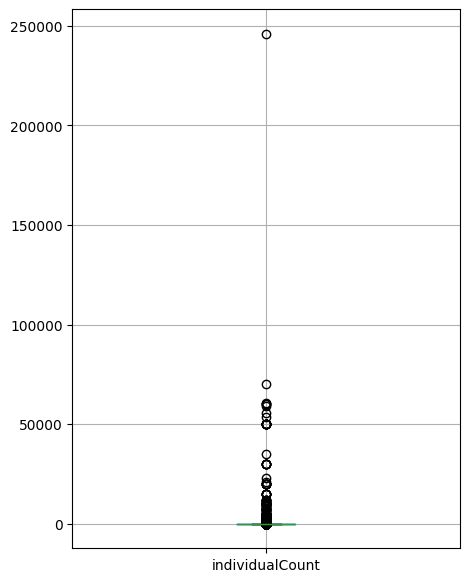

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,7))
oiseaux.boxplot(column='individualCount')
plt.show()

`individualCount` correspond au nombre d'individus observés pour une espèce donnée, à un instant donné et à une localisation donnée. Les valeurs qui se détachent sur le graphe sont des valeurs aberrantes (_outlier_). Du point de vue d'un néophyte, ces valeurs semblent être des erreurs : est-il possible d'observer plusieurs dizaines de millier d'oiseaux d'un coup ? Le point proche de 250 000 est très certainement une erreur.

16. Récupérer les valeurs contenues dans les colonnes `birdSpecies`, `departmentCode` et `individualCount` pour l'observation associée à la valeur maximale de `individualCount`.

    Faites quelques recherches sur l'espèce concernée. La valeur de `individualCount` vous paraît-elle plausible ? Justifiez et indiquez les liens des ressources sur lesquelles vous vous appuyez pour répondre.

In [40]:
oiseaux.loc[oiseaux.individualCount == oiseaux.individualCount.max(), ["birdSpecies","departmentCode","individualCount"]]

,birdSpecies,departmentCode,individualCount
1130052,Grus grus,51,246000


La page [Wikipédia](https://fr.wikipedia.org/wiki/Grue_cendr%C3%A9e) indique :
> La population mondiale de grues cendrées adultes est estimée en 2021 à 482 000 individus.

Il semble donc a priori peu probable que plus de la moitié de la population mondiale de grues cendrées ait pu être observée simultanément en un lieu.

Cependant, la suite de l'article Wikipédia indique :
> La France est un important pays d'accueil pour les grues venant y faire une halte ou pour hiverner. Les principaux sites fréquentés sont le lac du Der qui détient le record absolu d'individus présents simultanément (nombre estimé à 268 120 par les compteurs bénévoles de la LPO).

La LPO étant une source fiable, il semblerait donc que, aussi surprenant que cela puisse paraître, la valeur renseignée dans `individualCount` ne soit pas une erreur !